# Análisis Exploratorio de Datos

## Guia

https://spotintelligence.com/2023/09/15/exploratory-data-analysis-nlp/

## Problema de Investigación

## Categorías y Descripciones

1. **Economic**
- **Descripción**: Costos, beneficios u otras implicaciones financieras.
- **Ejemplo**: Artículos que analizan el impacto económico de las políticas de inmigración.

2. **Capacity and Resources**
- **Descripción**: Disponibilidad de recursos físicos, humanos o financieros, y la capacidad de los sistemas actuales.
- **Ejemplo**: Cobertura sobre la capacidad del sistema de salud durante una pandemia.

3. **Morality**
- **Descripción**: Implicaciones religiosas o éticas.
- **Ejemplo**: Debates sobre las leyes del aborto.

4. **Fairness and Equality**
- **Descripción**: Equilibrio o distribución de derechos, responsabilidades y recursos.
- **Ejemplo**: Discusiones sobre la desigualdad de ingresos y la justicia social.

5. **Legality, Constitutionality, and Jurisprudence**
- **Descripción**: Derechos, libertades y autoridad de individuos, corporaciones y el gobierno.
- **Ejemplo**: Análisis legales sobre nuevas legislaciones que afectan las libertades civiles.

6. **Policy Prescription and Evaluation**
- **Descripción**: Discusión sobre políticas específicas dirigidas a abordar problemas.
- **Ejemplo**: Opiniones sobre estrategias de mitigación del cambio climático.

7. **Crime and Punishment**
- **Descripción**: Efectividad e implicaciones de las leyes y su aplicación.
- **Ejemplo**: Informes sobre los esfuerzos de reforma del sistema de justicia penal.

8. **Security and Defense**
- **Descripción**: Amenazas al bienestar del individuo, la comunidad o la nación.
- **Ejemplo**: Preocupaciones sobre la seguridad nacional relacionadas con el control fronterizo.

9. **Health and Safety**
- **Descripción**: Atención médica, saneamiento y seguridad pública.
- **Ejemplo**: Medidas para combatir la propagación de enfermedades infecciosas.

10. **Quality of Life**
- **Descripción**: Amenazas y oportunidades para la riqueza, felicidad y bienestar del individuo.
- **Ejemplo**: El impacto del desarrollo urbano en el bienestar de los residentes.

11. **Cultural Identity**
- **Descripción**: Tradiciones, costumbres o valores de un grupo social en relación con un tema político.
- **Ejemplo**: Preservación de los idiomas y culturas indígenas.

12. **Public Opinion**
- **Descripción**: Actitudes y opiniones del público en general, incluidas encuestas y demografía.
- **Ejemplo**: Encuestas sobre el apoyo público a las fuentes de energía renovable.

13. **Political**
- **Descripción**: Consideraciones relacionadas con la política y los políticos, incluidas actividades de cabildeo, elecciones e intentos de influir en los votantes.
- **Ejemplo**: Estrategias de campaña electoral y esfuerzos de movilización de votantes.

14. **External Regulation and Reputation**
- **Descripción**: Reputación internacional o política exterior.
- **Ejemplo**: Relaciones diplomáticas y acuerdos internacionales.

15. **Other**
- **Descripción**: Cualquier grupo coherente de marcos no cubierto por las categorías anteriores.
- **Ejemplo**: Marcos únicos o emergentes específicos de problemas contemporáneos.


Datos tomados de: https://www.sciencedirect.com/science/article/pii/S2352340925000162

## Paso 1: Cargar Librerías

In [69]:
# !python -m spacy download es_core_news_sm

In [70]:
# !pip install networkx


In [115]:
# !pip install scipy

  Using cached scipy-1.15.2-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.15.2-cp311-cp311-win_amd64.whl (41.2 MB)



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import os
import string
import spacy
import networkx as nx

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud
from itertools import combinations


## Paso 2: Cargar Datos

In [72]:
df = pd.read_csv("../data/labels.csv")

In [73]:
import os

# Obtener la ruta actual del notebook
print("Directorio actual:", os.getcwd())


Directorio actual: C:\Users\guill\Documents\GitHub\nlp-media-framing\notebooks


In [74]:
# Ruta de la carpeta que contiene los archivos de texto
folder_path = "../data/articles/"

In [75]:
# Obtener la lista de archivos con extensión .txt en la carpeta
files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]

In [76]:
# Leer el contenido de cada archivo y almacenarlo en una lista
article_data = []
for file in files:
    with open(os.path.join(folder_path, file), "r", encoding="utf-8") as f:
        content = f.read()
        article_data.append(content)

In [77]:
# Crear un DataFrame con una columna "news"
df.insert(1, "news", article_data)

In [78]:
# Mostrar las primeras filas del DataFrame
df.head()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,policy_prescription_and_evaluation,crime_and_punishment,security_and_defense,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation
0,Noticia_1.txt,¿Cuánto tiempo estoy autorizado a permanecer e...,"['external_regulation_and_reputation', 'legali...",neutral,legality_constitutionality_and_jurisprudence,0,0,0,0,1,1,1,0,0,0,0,0,0,1
1,Noticia_2.txt,Colombia y Venezuela instalaron comisión de ve...,"['policy_prescription_and_evaluation', 'politi...",neutral,political,1,0,1,0,0,1,0,0,0,0,0,1,1,1
2,Noticia_7.txt,"Atrasar proceso electoral hasta enero de 2024,...","['political', 'quality_of_life', 'public_opini...",neutral,political,0,0,0,0,0,0,0,0,0,1,0,1,1,0
3,Noticia_8.txt,Avanza SLP en cuanto a transparencia presupues...,"['policy_prescription_and_evaluation', 'public...",neutral,policy_prescription_and_evaluation,0,0,0,0,0,1,0,0,0,0,0,1,0,1
4,Noticia_9.txt,Confía dirigente del PT en mantener el registr...,"['external_regulation_and_reputation', 'qualit...",negative,fairness_and_equality,0,1,0,1,0,1,0,0,0,1,0,1,0,1


In [79]:
df.tail()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,policy_prescription_and_evaluation,crime_and_punishment,security_and_defense,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation
135,Noticia_120.txt,Vacaciones de terror: agencia de viajes poblan...,"['public_opinion', 'political', 'quality_of_li...",neutral,political,0,0,0,0,0,0,0,0,0,1,0,1,1,0
136,Noticia_119.txt,"En SLP, la gasolina más barata se vende por de...","['capacity_and_resources', 'economic', 'politi...",neutral,economic,1,1,0,0,0,0,0,0,0,0,0,1,1,0
137,Noticia_118.txt,Inflación baja a 4.79% en la primera mitad de ...,"['security_and_defense', 'political']",positive,security_and_defense,0,0,0,0,0,0,0,1,0,0,0,0,1,0
138,Noticia_117.txt,Reducción de jornada laboral provocará un desp...,"['security_and_defense', 'morality', 'public_o...",neutral,security_and_defense,0,0,1,0,1,0,0,1,0,1,0,1,1,0
139,Noticia_116.txt,Advierte Ricardo Gallardo más cambios en su ga...,"['policy_prescription_and_evaluation', 'public...",positive,policy_prescription_and_evaluation,0,0,0,1,0,1,0,0,0,0,0,1,1,0


## Paso 1: Estadísticas básicas

In [80]:
def compute_statistics(text):
    word_count = len(text.split())  # Number of words
    char_count = len(text)  # Number of characters
    sentence_count = len(re.split(r'[.!?]', text)) - 1  # Number of sentences
    avg_word_length = sum(len(word) for word in text.split()) / word_count if word_count > 0 else 0  # Average word length
    return pd.Series([word_count, char_count, sentence_count, avg_word_length],
                     index=['word_count', 'character_count', 'sentence_count', 'average_word_length'])

In [81]:
# Apply function to dataset
data_stats = df['news'].apply(compute_statistics)

# Combine with original data
result = pd.concat([df, data_stats], axis=1)

# Display results
result

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,...,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation,word_count,character_count,sentence_count,average_word_length
0,Noticia_1.txt,¿Cuánto tiempo estoy autorizado a permanecer e...,"['external_regulation_and_reputation', 'legali...",neutral,legality_constitutionality_and_jurisprudence,0,0,0,0,1,...,0,0,0,0,0,1,512.0,3148.0,25.0,4.976562
1,Noticia_2.txt,Colombia y Venezuela instalaron comisión de ve...,"['policy_prescription_and_evaluation', 'politi...",neutral,political,1,0,1,0,0,...,0,0,0,1,1,1,423.0,2661.0,16.0,5.210402
2,Noticia_7.txt,"Atrasar proceso electoral hasta enero de 2024,...","['political', 'quality_of_life', 'public_opini...",neutral,political,0,0,0,0,0,...,0,1,0,1,1,0,316.0,2023.0,5.0,5.395570
3,Noticia_8.txt,Avanza SLP en cuanto a transparencia presupues...,"['policy_prescription_and_evaluation', 'public...",neutral,policy_prescription_and_evaluation,0,0,0,0,0,...,0,0,0,1,0,1,338.0,1934.0,7.0,4.713018
4,Noticia_9.txt,Confía dirigente del PT en mantener el registr...,"['external_regulation_and_reputation', 'qualit...",negative,fairness_and_equality,0,1,0,1,0,...,0,1,0,1,0,1,323.0,1890.0,4.0,4.848297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,Noticia_120.txt,Vacaciones de terror: agencia de viajes poblan...,"['public_opinion', 'political', 'quality_of_li...",neutral,political,0,0,0,0,0,...,0,1,0,1,1,0,483.0,2914.0,12.0,5.026915
136,Noticia_119.txt,"En SLP, la gasolina más barata se vende por de...","['capacity_and_resources', 'economic', 'politi...",neutral,economic,1,1,0,0,0,...,0,0,0,1,1,0,262.0,1395.0,16.0,4.320611
137,Noticia_118.txt,Inflación baja a 4.79% en la primera mitad de ...,"['security_and_defense', 'political']",positive,security_and_defense,0,0,0,0,0,...,0,0,0,0,1,0,359.0,2146.0,29.0,4.974930
138,Noticia_117.txt,Reducción de jornada laboral provocará un desp...,"['security_and_defense', 'morality', 'public_o...",neutral,security_and_defense,0,0,1,0,1,...,0,1,0,1,1,0,443.0,2795.0,11.0,5.306998


### Paso 1.1 Conteo de Palabras

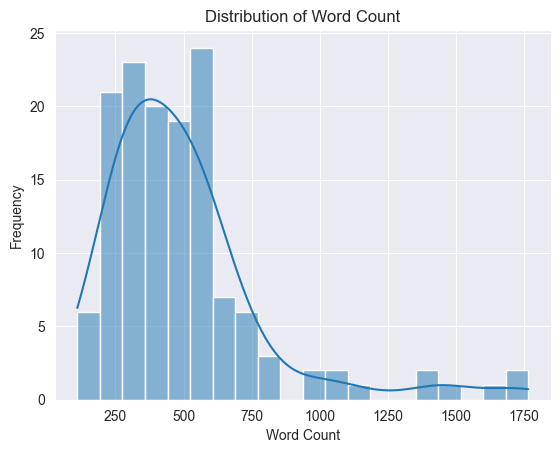

In [82]:
sns.histplot(data=result, x="word_count", bins=20, kde=True)

# Improve readability
plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### Paso 1.2 Conteo de caracteres

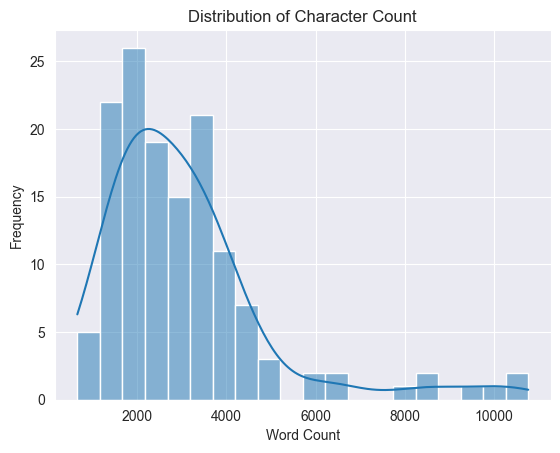

In [83]:
sns.histplot(data=result, x="character_count", bins=20, kde=True)

# Improve readability
plt.title("Distribution of Character Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### Paso 1.3: conteo de oraciones

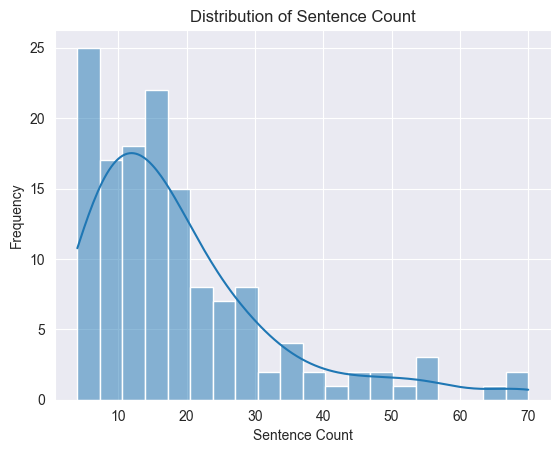

In [84]:
sns.histplot(data=result, x="sentence_count", bins=20, kde=True)

# Improve readability
plt.title("Distribution of Sentence Count")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.show()

### Paso 1.4: longitud promedio de palabra

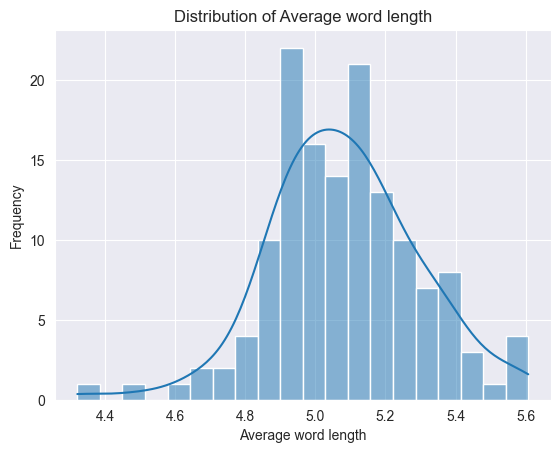

In [85]:
sns.histplot(data=result, x="average_word_length", bins=20, kde=True)

# Improve readability
plt.title("Distribution of Average word length")
plt.xlabel("Average word length")
plt.ylabel("Frequency")
plt.show()

## Paso 2: Tokenización

### Paso 2.1: Word Tokenization

In [86]:
df["word_tokens"] = df["news"].apply(lambda text: word_tokenize(text.lower()))

In [87]:
df["word_tokens"]

0      [¿cuánto, tiempo, estoy, autorizado, a, perman...
1      [colombia, y, venezuela, instalaron, comisión,...
2      [atrasar, proceso, electoral, hasta, enero, de...
3      [avanza, slp, en, cuanto, a, transparencia, pr...
4      [confía, dirigente, del, pt, en, mantener, el,...
                             ...                        
135    [vacaciones, de, terror, :, agencia, de, viaje...
136    [en, slp, ,, la, gasolina, más, barata, se, ve...
137    [inflación, baja, a, 4.79, %, en, la, primera,...
138    [reducción, de, jornada, laboral, provocará, u...
139    [advierte, ricardo, gallardo, más, cambios, en...
Name: word_tokens, Length: 140, dtype: object

### Paso 2.2: Sentence Tokenization

In [88]:
df["sentence_tokens"] = df["news"].apply(lambda text: sent_tokenize(text))

In [89]:
df["sentence_tokens"]

0      [¿Cuánto tiempo estoy autorizado a permanecer ...
1      [Colombia y Venezuela instalaron comisión de v...
2      [Atrasar proceso electoral hasta enero de 2024...
3      [Avanza SLP en cuanto a transparencia presupue...
4      [Confía dirigente del PT en mantener el regist...
                             ...                        
135    [Vacaciones de terror: agencia de viajes pobla...
136    [En SLP, la gasolina más barata se vende por d...
137    [Inflación baja a 4.79% en la primera mitad de...
138    [Reducción de jornada laboral provocará un des...
139    [Advierte Ricardo Gallardo más cambios en su g...
Name: sentence_tokens, Length: 140, dtype: object

## Paso 3: Análisis de Stopwords

### Paso 3.1: Remover los Stopwords

In [90]:
# Create a set of stop words
spanish_stopwords = set(stopwords.words('spanish'))

In [91]:
# Combine all text in the "news" column
text = " ".join(df["news"].dropna())

# Remove punctuation and stopwords
text_cleaned = " ".join([
    re.sub(r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', '', word)  # Keep only letters
    for word in text.split()
    if word.lower() not in spanish_stopwords and word not in string.punctuation
])


### Paso 3.2: Frecuencia de los Stopwords

In [92]:
all_tokens = [word for sublist in df["word_tokens"] for word in sublist]

In [93]:
stopword_counts = Counter([word for word in all_tokens if word in spanish_stopwords])

In [94]:
# Convert to DataFrame for visualization
df_stopwords = (pd.DataFrame(stopword_counts.items(), columns=['Stopword', 'Frequency'])
                .sort_values(by='Frequency', ascending=False)
                .head(20))

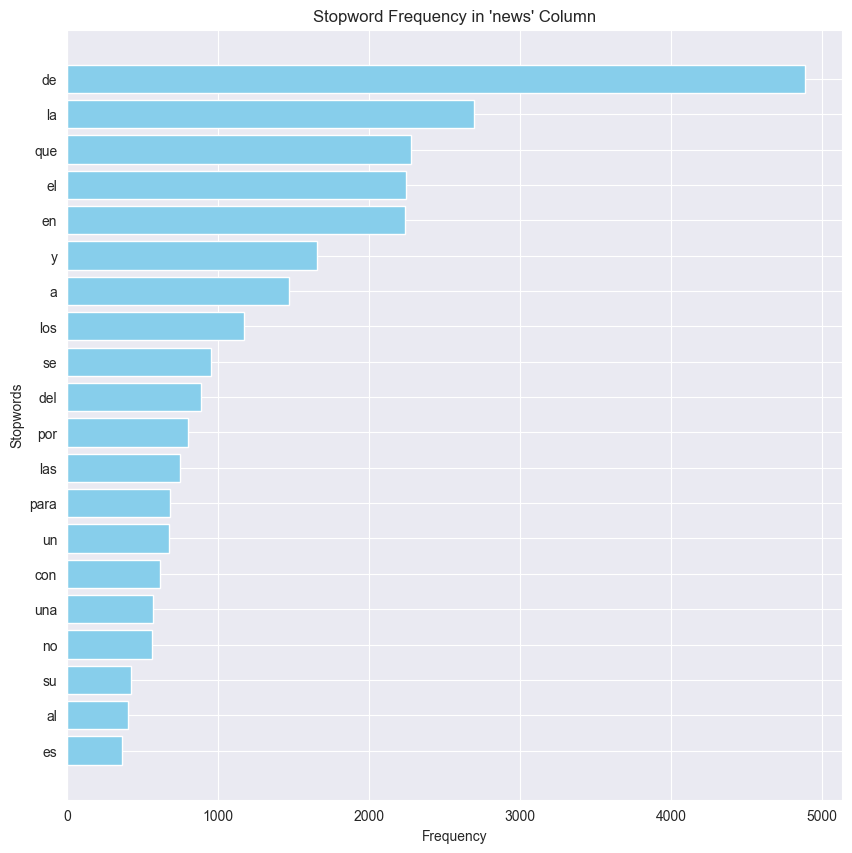

In [95]:
# Plot the stopword frequency
plt.figure(figsize=(10, 10))
plt.barh(df_stopwords['Stopword'], df_stopwords['Frequency'], color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Stopwords")
plt.title("Stopword Frequency in 'news' Column")
plt.gca().invert_yaxis()  # Invert to show the highest frequency on top
plt.show()

## Paso 4: Descripción de Datos en NLP durante el Análisis Exploratorio de Datos

## Paso 5: Visualización de Datos en NLP para el Análisis Exploratorio de Datos

### Paso 5.1: Nubes de Palabras

In [96]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_cleaned)

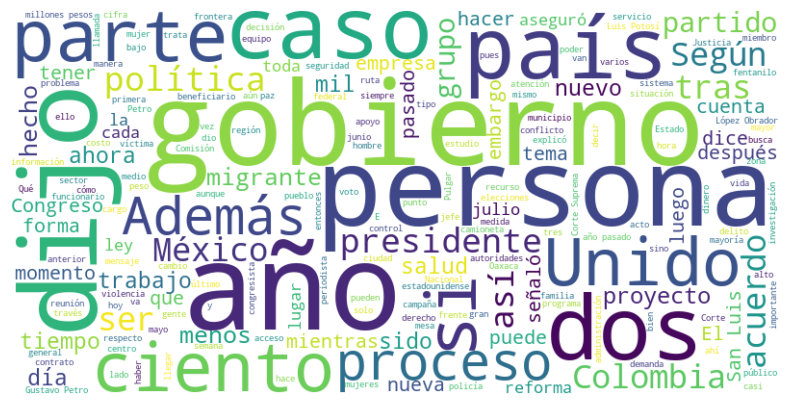

In [97]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Paso 5.2: Frequency Distribution Plots

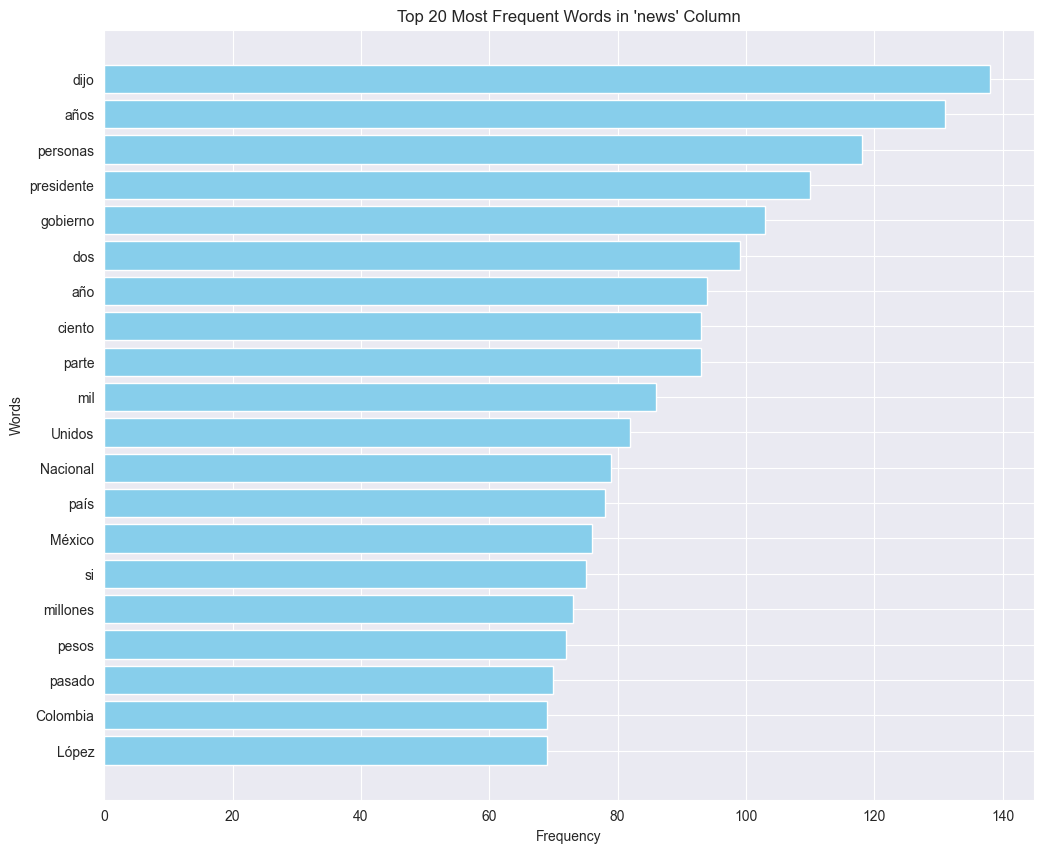

In [98]:
# Tokenize the cleaned text
tokens = word_tokenize(text_cleaned)

# Count word frequencies
word_counts = Counter(tokens)

# Convert to DataFrame and sort by frequency
df_word_freq = (pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])
                .sort_values(by='Frequency', ascending=False))

# Select top N words (e.g., 20)
N = 20
top_words = df_word_freq.head(N)

# Plot bar chart
plt.figure(figsize=(12, 10))
plt.barh(top_words['Word'], top_words['Frequency'], color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title(f"Top {N} Most Frequent Words in 'news' Column")
plt.gca().invert_yaxis()  # Highest frequency on top
plt.show()

### Paso 5.3: El análisis de N-grams

In [99]:
def clean_text(text):
    """
    Limpia el texto eliminando signos de puntuación, números, stopwords y convirtiendo a minúsculas.
    """
    # Convertir a minúsculas
    text = text.lower()

    # Eliminar signos de puntuación
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)

    # Eliminar números
    text = re.sub(r'\d+', '', text)

    # Eliminar stopwords
    stop_words = set(stopwords.words('spanish'))  # Cambia 'spanish' por el idioma que necesites
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]  # Solo palabras alfabéticas

    return tokens

In [100]:
def generate_ngramas(text, n):
    """
    Genera n-gramas a partir de un texto limpio.
    """
    # Limpiar el texto
    tokens = clean_text(text)

    # Generar n-gramas
    return list(ngrams(tokens, n))

#### Paso 5.3.1: Bigrams

In [101]:
# Aplicar la función a cada fila de la columna 'news'
df['bigramas'] = df['news'].apply(lambda x: generate_ngramas(x, 2))

In [102]:
# Combinar todos los n-gramas en una sola lista
todos_los_bigramas = [bigrama for sublist in df['bigramas'] for bigrama in sublist]

# Contar la frecuencia de cada n-grama
frecuencia_bigramas = Counter(todos_los_bigramas)

# Mostrar los n-gramas más comunes
print(frecuencia_bigramas.most_common(10))

[(('san', 'luis'), 43), (('lópez', 'obrador'), 39), (('luis', 'potosí'), 38), (('año', 'pasado'), 31), (('millones', 'pesos'), 30), (('gustavo', 'petro'), 29), (('corte', 'suprema'), 23), (('redes', 'sociales'), 18), (('millones', 'dólares'), 18), (('andrés', 'manuel'), 17)]


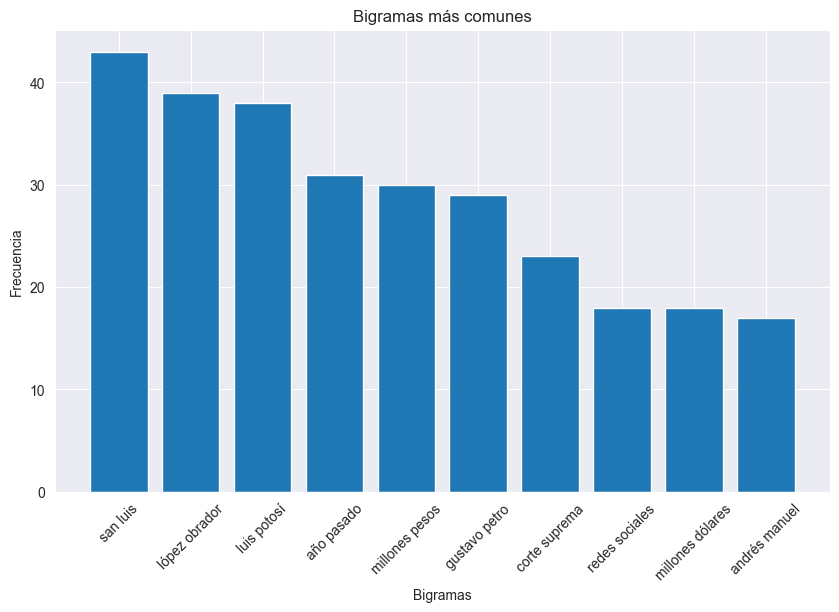

In [103]:
# Convertir a DataFrame para facilitar la visualización
df_frecuencia = pd.DataFrame(frecuencia_bigramas.most_common(10), columns=['Bigrama', 'Frecuencia'])
df_frecuencia['Bigrama'] = df_frecuencia['Bigrama'].apply(lambda x: ' '.join(x))

# Graficar
plt.figure(figsize=(10, 6))
plt.bar(df_frecuencia['Bigrama'], df_frecuencia['Frecuencia'])
plt.xlabel('Bigramas')
plt.ylabel('Frecuencia')
plt.title('Bigramas más comunes')
plt.xticks(rotation=45)
plt.show()

#### Paso 5.3.2: Trigrams

In [104]:
df['trigrams'] = df['news'].apply(lambda x: generate_ngramas(x, 3))

In [105]:
# Combinar todos los n-gramas en una sola lista
todos_los_trigrams = [trigram for sublist in df['trigrams'] for trigram in sublist]

# Contar la frecuencia de cada n-grama
frecuencia_trigrams = Counter(todos_los_trigrams)

# Mostrar los n-gramas más comunes
print(frecuencia_trigrams.most_common(10))

[(('san', 'luis', 'potosí'), 38), (('andrés', 'manuel', 'lópez'), 17), (('manuel', 'lópez', 'obrador'), 17), (('presidente', 'andrés', 'manuel'), 16), (('permiso', 'permanencia', 'temporal'), 15), (('presidente', 'gustavo', 'petro'), 12), (('presidente', 'lópez', 'obrador'), 12), (('mil', 'millones', 'pesos'), 10), (('hudson', 's', 'bay'), 10), (('consejo', 'nacional', 'electoral'), 8)]


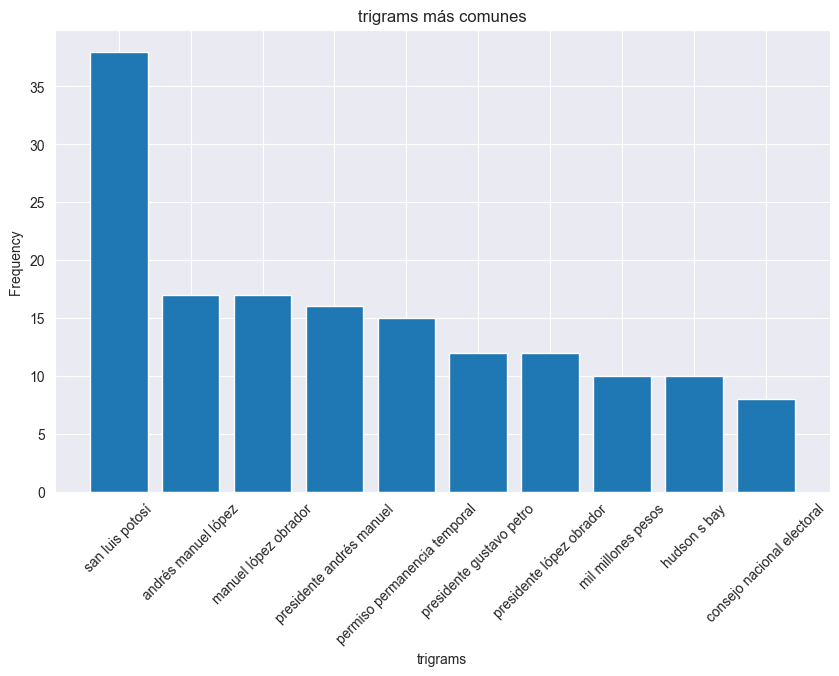

In [106]:
# Convertir a DataFrame para facilitar la visualización
df_trigram_frequency = pd.DataFrame(frecuencia_trigrams.most_common(10), columns=['trigrams', 'Frequency'])
df_trigram_frequency['trigrams'] = df_trigram_frequency['trigrams'].apply(lambda x: ' '.join(x))

# Graficar
plt.figure(figsize=(10, 6))
plt.bar(df_trigram_frequency['trigrams'], df_trigram_frequency['Frequency'])
plt.xlabel('trigrams')
plt.ylabel('Frequency ')
plt.title('trigrams más comunes')
plt.xticks(rotation=45)
plt.show()

### Paso 5.4: Gráficos de Análisis de Sentimientos

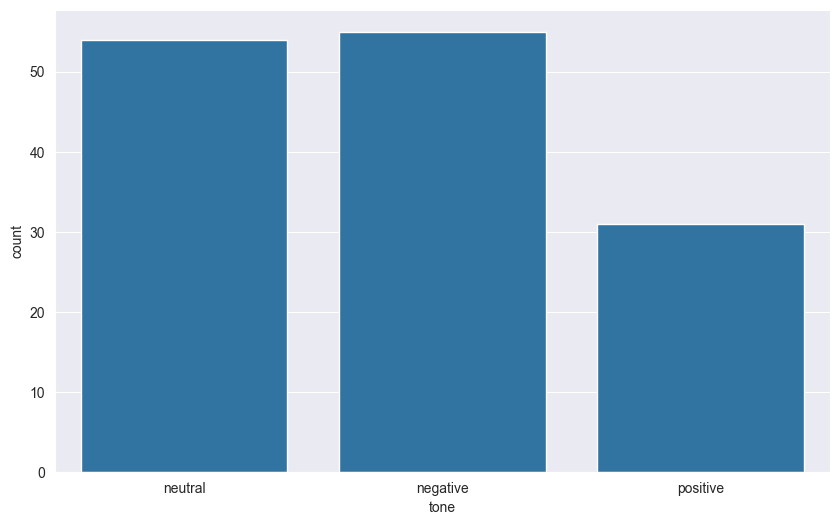

In [107]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="tone")
plt.show()

### Paso 5.5: Named Entity Recognition (NER)

#### Paso 5.5.1: NER Tags

In [108]:
# Load Spanish spaCy model
nlp = spacy.load("es_core_news_sm")
doc = nlp(text_cleaned)

In [109]:
# Extract entity labels
entities = [ent.label_ for ent in doc.ents]
entity_counts = Counter(entities)

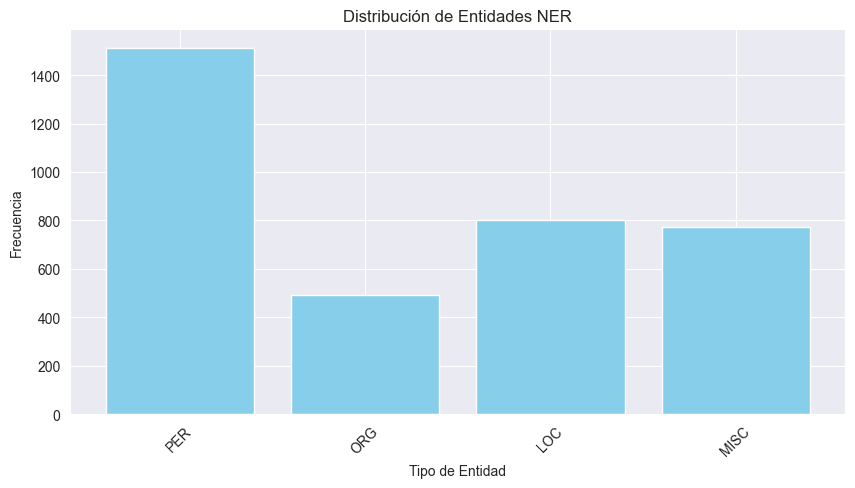

In [110]:
# Bar chart for entity distribution
plt.figure(figsize=(10, 5))
plt.bar(entity_counts.keys(), entity_counts.values(), color='skyblue')
plt.xlabel("Tipo de Entidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de Entidades NER")
plt.xticks(rotation=45)
plt.show()

In [111]:
# WordCloud for Named Entities
entity_text = " ".join([ent.text for ent in doc.ents])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(entity_text)

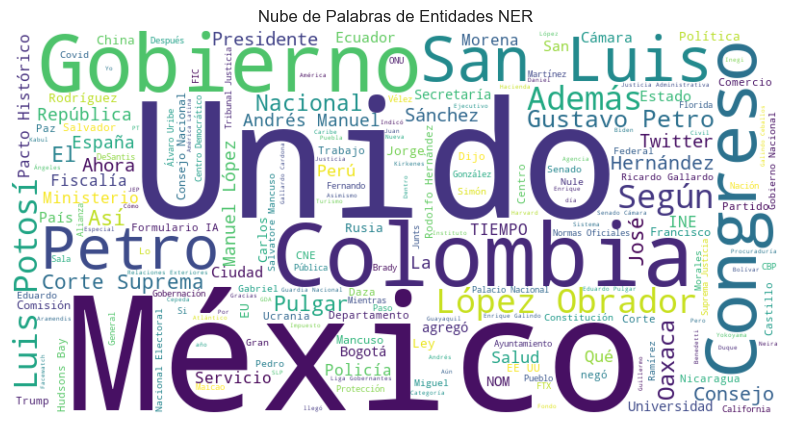

In [112]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras de Entidades NER")
plt.show()

#### Paso 5.5.2: Entity Co-occurrence

In [116]:
# Extract entity pairs from sentences
entity_pairs = []
for sent in doc.sents:
    entities = [ent.text for ent in sent.ents if ent.label_ in ["PER", "ORG", "LOC", "MISC"]]  # Only specific entity types
    entity_pairs.extend(combinations(entities, 2))  # Create entity co-occurrence pairs

# Count entity co-occurrence
co_occurrence_counts = Counter(entity_pairs)

# Build Graph
G = nx.Graph()
for (entity1, entity2), count in co_occurrence_counts.items():
    G.add_edge(entity1, entity2, weight=count)

# Plot Network Graph
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
edges = G.edges(data=True)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color="skyblue", edge_color="gray", node_size=3000, font_size=10, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in edges}, font_size=8)

plt.title("Entity Co-occurrence Graph")
plt.show()


KeyboardInterrupt: 

### Paso 5.6: Visualización de Etiquetado de Partes del Discurso (POS)

#### Paso 5.6.1: POS Tag Distribution

C:\Users\guill\AppData\Local\Temp\ipykernel_8448\1279354480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[tag for tag, _ in pos_sorted], y=[count for _, count in pos_sorted], palette="Blues_r")


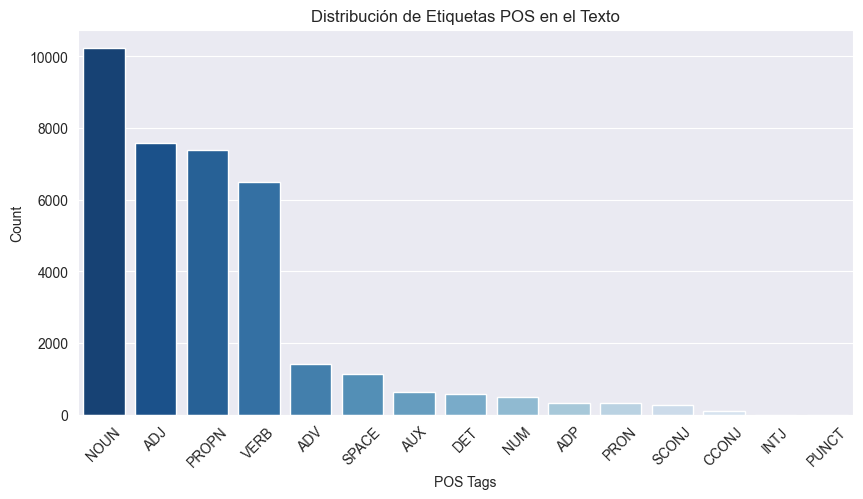

In [117]:
# Extract POS tags
pos_tags = [token.pos_ for token in doc if not token.is_punct]  # Ignore punctuation
pos_counts = Counter(pos_tags)

# Convert to sorted list (high to low frequency)
pos_sorted = sorted(pos_counts.items(), key=lambda x: x[1], reverse=True)

# Plot POS Distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=[tag for tag, _ in pos_sorted], y=[count for _, count in pos_sorted], palette="Blues_r")
plt.xlabel("POS Tags")
plt.ylabel("Count")
plt.title("Distribución de Etiquetas POS en el Texto")
plt.xticks(rotation=45)
plt.show()

#### Paso 5.6.2: POS Tag Transition Matrix

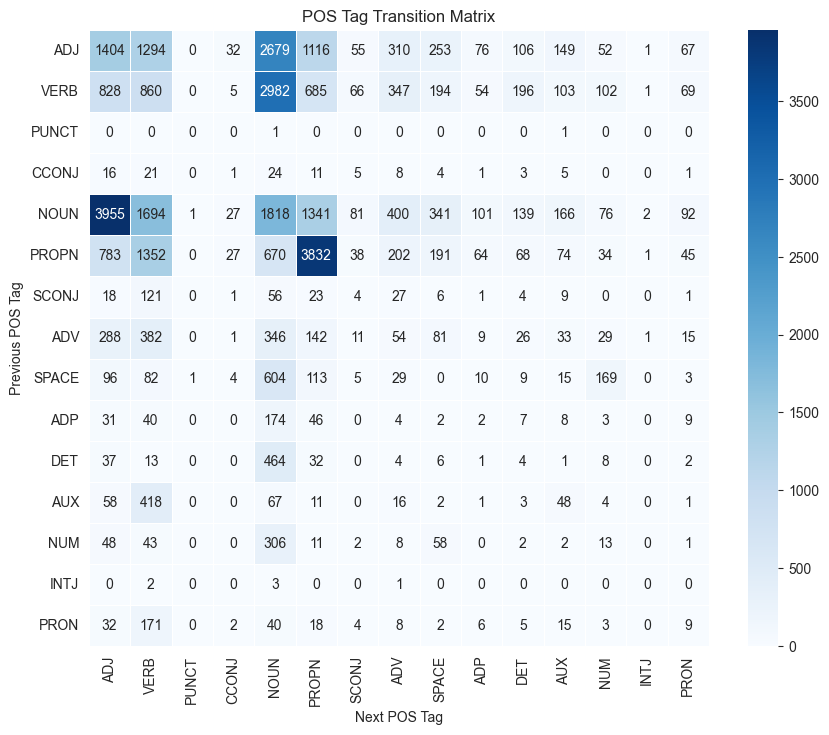

In [118]:
from collections import defaultdict

# Extract POS transitions
pos_transitions = defaultdict(lambda: defaultdict(int))  # Nested dictionary for counting transitions

# Iterate through token pairs (previous and current)
previous_pos = None
for token in doc:
    if not token.is_punct:  # Ignore punctuation
        current_pos = token.pos_
        if previous_pos:
            pos_transitions[previous_pos][current_pos] += 1
        previous_pos = current_pos

# Convert to DataFrame
pos_tags = list(set(pos_transitions.keys()) | set(tag for sub in pos_transitions.values() for tag in sub))  # Unique POS tags
matrix = pd.DataFrame(np.zeros((len(pos_tags), len(pos_tags))), index=pos_tags, columns=pos_tags)

# Fill transition matrix
for prev, next_tags in pos_transitions.items():
    for next_tag, count in next_tags.items():
        matrix.loc[prev, next_tag] = count

# Normalize by row (optional: uncomment for probability matrix)
# matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".0f", linewidths=0.5)
plt.xlabel("Next POS Tag")
plt.ylabel("Previous POS Tag")
plt.title("POS Tag Transition Matrix")
plt.show()

## Procesamiento de datos